In [2]:
import pandas as pd
import numpy as np

Load dataset into pandas dataframe

In [3]:
df = pd.read_csv('data/sentiment-analysis.csv', delimiter=',')

# print head of dataframe
df.head()

,"Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score"
0,"""I love this product!"", Positive, Twitter, 202..."
1,"""The service was terrible."", Negative, Yelp Re..."
2,"""This movie is amazing!"", Positive, IMDb, 2023..."
3,"""I'm so disappointed with their customer suppo..."
4,"""Just had the best meal of my life!"", Positive..."


The dataframe failed to parse the data correctly. We can see there are 7 columns. Let's solve this by splitting it manually. And clean the data

In [5]:
# split the columns 
df = df['Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score'].str.split(',', expand=True)

,0,1,2,3,4,5,6
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88


Columns were splitted successfully. We can see there right column names are not there, instead integers (0,1...n). This is because the split function does not have any contextual information to split the columns with their names. We can fix that by setting the columns ourselves.

In [7]:
df.columns = ['Text', 'Sentiment', 'Source', 'Date/Time','User ID', 'Location', 'Confidence Score']
df.head(5)

,Text,Sentiment,Source,Date/Time,User ID,Location,Confidence Score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Text              96 non-null     object
 1   Sentiment         96 non-null     object
 2   Source            96 non-null     object
 3   Date/Time         96 non-null     object
 4   User ID           96 non-null     object
 5   Location          96 non-null     object
 6   Confidence Score  96 non-null     object
dtypes: object(7)
memory usage: 5.5+ KB


There are no nulls in this dataset. Because of the nature of the dataset, let's go ahead and perform related data cleaning processes.

In [10]:
# check unique values
# Unique values for 'Sentiment'

print(df['Sentiment'].unique())

[' Positive' ' Negative' nan]


In [11]:
# unique values for location
print(df['Location'].unique())

[' New York' ' Los Angeles' ' London' ' Toronto' ' Paris' ' San Francisco'
 ' Berlin' ' Sydney' ' Mumbai' ' Orlando' ' Chicago' nan]


In [16]:
df['Confidence Score'].head()

0    0.85
1    0.65
2    0.92
3    0.78
4    0.88
Name: Confidence Score, dtype: object

In [12]:
# strip extra whitespaces from columns
for col in df.columns:
    df[col] = df[col].str.strip()

In [17]:
# convert 'Date/Time' dtype to datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')

# convert 'Sentiment' to category
df['Sentiment'] = df['Sentiment'].astype('category')

# convert 'Confidence Score to float'
df['Confidence Score'] = df['Confidence Score'].astype('float64')

df.head(5)

,Text,Sentiment,Source,Date/Time,User ID,Location,Confidence Score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Text              96 non-null     object        
 1   Sentiment         96 non-null     category      
 2   Source            96 non-null     object        
 3   Date/Time         96 non-null     datetime64[ns]
 4   User ID           96 non-null     object        
 5   Location          96 non-null     object        
 6   Confidence Score  96 non-null     float64       
dtypes: category(1), datetime64[ns](1), float64(1), object(4)
memory usage: 4.9+ KB


Now we have optmized the dataset's memory usage. 

Moving on... Let's map the 'Sentiment' to NPS categories
- Promoters
- Passives
- Detractors

In [22]:
def map_sentiment(sentiment):
    if sentiment == 'Positive':
        return 'Promoter'
    elif sentiment == 'Neutral':
        return 'Passive'
    elif sentiment == 'Negative':
        return 'Detractor'
    else:
        return 'Unknown'

# apply function on df
df['NPS_Category'] = df['Sentiment'].apply(map_sentiment)

df[['Text', 'Source', 'User ID', 'Sentiment', 'Confidence Score', 'NPS_Category']].head()
        
    

,Text,Source,User ID,Sentiment,Confidence Score,NPS_Category
0,"""I love this product!""",Twitter,@user123,Positive,0.85,Promoter
1,"""The service was terrible.""",Yelp Reviews,user456,Negative,0.65,Detractor
2,"""This movie is amazing!""",IMDb,moviefan789,Positive,0.92,Promoter
3,"""I'm so disappointed with their customer suppo...",Online Forum,forumuser1,Negative,0.78,Detractor
4,"""Just had the best meal of my life!""",TripAdvisor,foodie22,Positive,0.88,Promoter


That was just the first step in finding the Net Promoter Scores of our customers. We have to find the percentages of each indicator and calculate the NPS.

In [25]:
# Calculate the percentages

total = len(df)

promoters = round(len(df[df['NPS_Category'] == 'Promoter']) / total * 100, 2)

detractors = round(len(df[df['NPS_Category'] == 'Detractor']) / total * 100 , 2)

nps = promoters - detractors

print(f'The Percentage of Promoters: {promoters}')
print(f'The percentage of Detractors: {detractors}')
print(f'The NPS is: {nps: .2f}')

The Percentage of Promoters: 54.08
The percentage of Detractors: 43.88
The NPS is:  10.20


- The 54.08 percentage of our customers suggest we have more than half of our customer base who are satisisfied with our product and would be willing to continue using our products, and recommend to others
- The 43.88 is significantly high. It means there are almost half of our customer base who are not satisfied with our product, and these clients are susceptible to competitive offerings. Understanding their concerns would be the first step retain and regain confidence.
- NPS of 10.20 is low, but tells us that we have a majority of customer willing to work with us still.

In [32]:
grouped_sources = df.groupby('Source')

for source, group in source_group:
    promoters = len(group[group['NPS_Category'] == 'Promoter']) /len(group) * 100
    detractors = len(group[group['NPS_Category'] == 'Detractor']) /len(group) * 100
    nps = promoters - detractors

    print(f"Source: {source}, NPS: {nps: .2f}")

Source: Airline Review, NPS: -100.00
Source: Amazon Reviews, NPS: -100.00
Source: Art Review, NPS:  100.00
Source: Event Review, NPS:  100.00
Source: Food Blog, NPS:  100.00
Source: Gaming Forum, NPS:  100.00
Source: Goodreads, NPS:  33.33
Source: Hotel Review, NPS: -100.00
Source: IMDb, NPS:  66.67
Source: Music Review, NPS:  100.00
Source: Online Chat, NPS:  0.00
Source: Online Forum, NPS: -100.00
Source: Online Helpdesk, NPS: -100.00
Source: Online Store, NPS: -81.82
Source: Retail Store, NPS:  100.00
Source: Spotify, NPS:  100.00
Source: TV Show Review, NPS: -100.00
Source: Theme Park Review, NPS:  100.00
Source: Travel Blog, NPS:  100.00
Source: Travel Website, NPS: -100.00
Source: Trip Report, NPS:  100.00
Source: TripAdvisor, NPS:  100.00
Source: Twitter, NPS:  100.00
Source: Website Review, NPS: -100.00
Source: Website Testimonial, NPS:  100.00
Source: Yelp Reviews, NPS: -33.33
Source: Zomato, NPS: -71.43


We can this distinct NPS for each source. Most have a good customer base like Spotify, Retail Store. Likewise a significant number of people also have a negative NPS at -100, which means complete disatisfaction from clients, and wouldn't recommend.

### Visualizations

In [35]:
import matplotlib.pyplot as plt

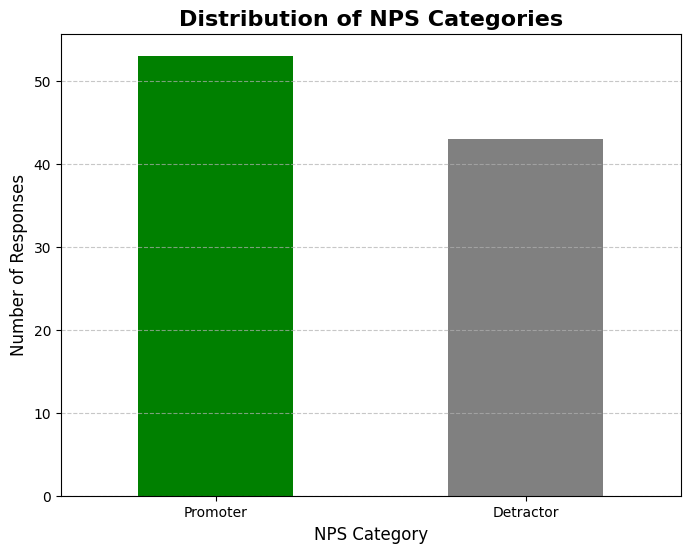

In [36]:
# visualization 1: Distribution of NPS categories

nps_counts = df['NPS_Category'].value_counts()

plt.figure(figsize=(8,6))
nps_counts.plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Distribution of NPS Categories', fontsize=16, fontweight='bold')
plt.xlabel('NPS Category', fontsize=12)
plt.ylabel('Number of Responses', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<hr>

C:\Users\White\AppData\Local\Temp\ipykernel_23848\591652476.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nps_by_source = df.groupby('Source').apply(


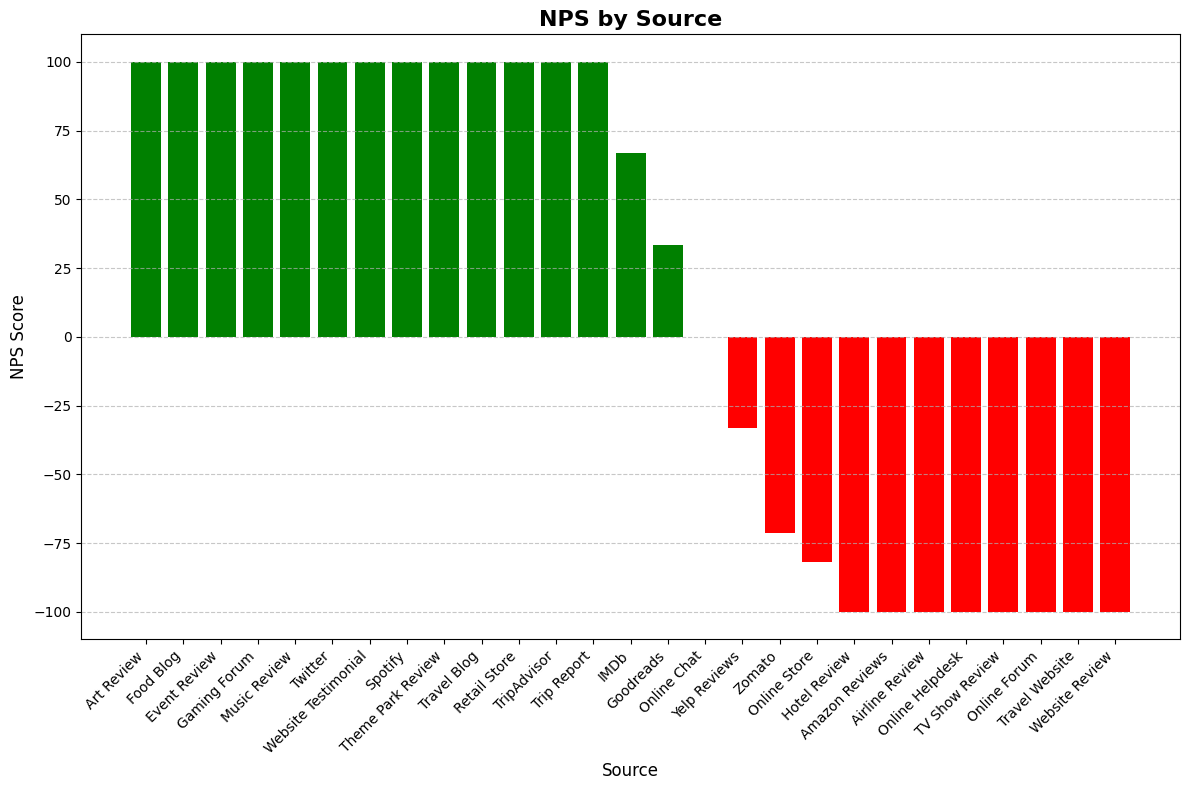

In [37]:
# Visualization 2: NPS by Source

nps_by_source = df.groupby('Source').apply(
    lambda x: (len(x[x['NPS_Category'] == 'Promoter']) - len(x[x['NPS_Category'] == 'Detractor'])) / len(x) * 100
).reset_index(name='NPS')
nps_by_source = nps_by_source.sort_values(by='NPS', ascending=False)

plt.figure(figsize=(12, 8))
plt.bar(nps_by_source['Source'], nps_by_source['NPS'],
        color=nps_by_source['NPS'].apply(lambda x: 'green' if x > 0 else ('red' if x < 0 else 'gray')))
plt.title('NPS by Source', fontsize=16, fontweight='bold')
plt.xlabel('Source', fontsize=12)
plt.ylabel('NPS Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\White\AppData\Local\Temp\ipykernel_23848\1623467600.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sentiment_trend = df.groupby(['Date', 'Sentiment']).size().unstack(fill_value=0)


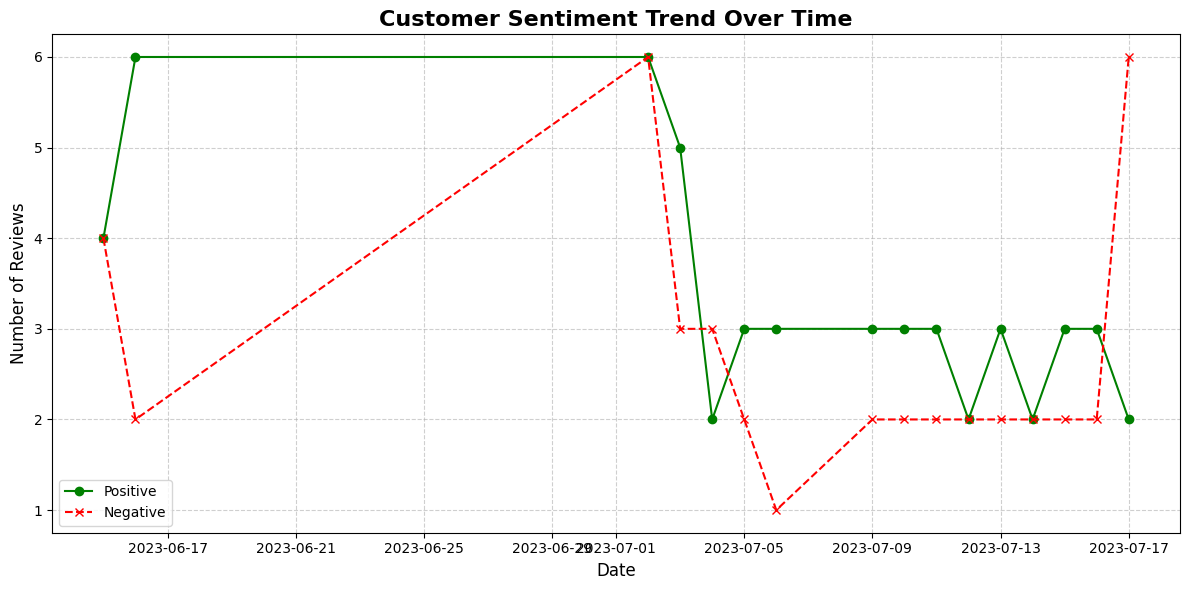

In [38]:
# Visualization 3: Sentiment trend over time
df['Date'] = df['Date/Time'].dt.date
sentiment_trend = df.groupby(['Date', 'Sentiment']).size().unstack(fill_value=0)
sentiment_trend.index = pd.to_datetime(sentiment_trend.index)

plt.figure(figsize=(12, 6))
plt.plot(sentiment_trend.index, sentiment_trend.get('Positive', pd.Series(0, index=sentiment_trend.index)),
         label='Positive', marker='o', linestyle='-', color='green')
plt.plot(sentiment_trend.index, sentiment_trend.get('Negative', pd.Series(0, index=sentiment_trend.index)),
         label='Negative', marker='x', linestyle='--', color='red')
plt.title('Customer Sentiment Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
